In [1]:
from firebase_admin.firestore import DocumentSnapshot, DocumentReference, SERVER_TIMESTAMP
from firebase_admin import firestore

import pandas as pd
import matplotlib.pyplot as plt

from firestore_db import db

In [20]:
posts = db.collection(u"random_posts").get()

data = []
for post in posts:
  post_dict: dict[str, str | list[DocumentReference]] = post.to_dict()
  created_at = post_dict.get("created_at")
  authors = post_dict.get("authors", [])

  for author in authors:
    author_data = author.get().to_dict()
    data.append({
      "created_at": created_at,
      "author": f"{author_data['firstname']} {author_data['lastname']}"
    })
    
data

[{'created_at': '2025-02-19T15:06:58.858965', 'author': 'Cyrille Latour'},
 {'created_at': '2025-02-19T15:06:58.858965', 'author': 'Naomi Giotto'},
 {'created_at': '2025-02-17T10:15:10.507909', 'author': 'Naomi Giotto'},
 {'created_at': '2025-02-17T10:15:10.507909', 'author': 'Cyrille Latour'},
 {'created_at': '2025-02-20T04:09:53.526240', 'author': 'Cyrille Latour'},
 {'created_at': '2025-02-20T06:38:55.119951', 'author': 'Antonio Pisanello'},
 {'created_at': '2025-02-20T06:38:55.119951', 'author': 'Cyrille Latour'},
 {'created_at': '2025-02-19T02:16:12.211211', 'author': 'Cyrille Latour'},
 {'created_at': '2025-02-18T13:46:25.184923', 'author': 'Antonio Pisanello'},
 {'created_at': '2025-02-18T07:38:15.351739', 'author': 'Cyrille Latour'},
 {'created_at': '2025-02-18T07:38:15.351739', 'author': 'Naomi Giotto'},
 {'created_at': '2025-02-18T23:26:41.195403', 'author': 'Naomi Giotto'},
 {'created_at': '2025-02-18T23:26:41.195403', 'author': 'Antonio Pisanello'},
 {'created_at': '2025-02

In [ ]:
df = pd.DataFrame(data)
df["created_at"] = pd.to_datetime(df["created_at"])
df["date"] = df["created_at"].dt.date

,0
0,2025-02-19 15:06:58.858965
1,2025-02-17 10:15:10.507909
2,2025-02-20 04:09:53.526240
3,2025-02-20 06:38:55.119951
4,2025-02-19 02:16:12.211211
5,2025-02-18 13:46:25.184923
6,2025-02-18 07:38:15.351739
7,2025-02-18 23:26:41.195403
8,2025-02-18 14:57:49.304894
9,2025-02-19 15:29:42.942692


In [ ]:
df_unique = df[df.created_at.isin()]

In [11]:
post_counts = df.groupby("date").size().reset_index(name="post_counts")
post_counts

,date,post_counts
0,2025-02-17,5
1,2025-02-18,6
2,2025-02-19,5
3,2025-02-20,4


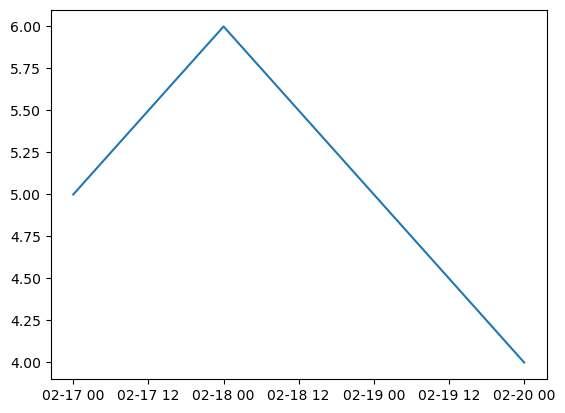

In [15]:
plt.plot(post_counts.date, post_counts.post_counts)

<BarContainer object of 4 artists>

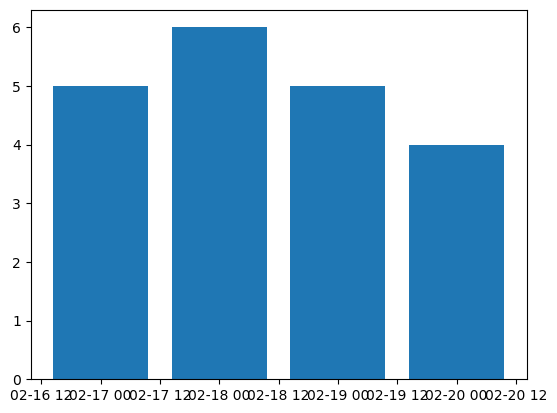

In [13]:
plt.bar(post_counts.date, post_counts.post_counts)

In [17]:
df.groupby(["date", "authors"]).size()

TypeError: unhashable type: 'list'